In [1]:
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../models/random_forest_tuned.pkl")

X_train = joblib.load("../data/processed/X_train.pkl")
X_test = joblib.load("../data/processed/X_test.pkl")

feature_df = pd.read_csv("../reports/selected_features.csv")

feature_names = feature_df["Feature"].tolist()

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

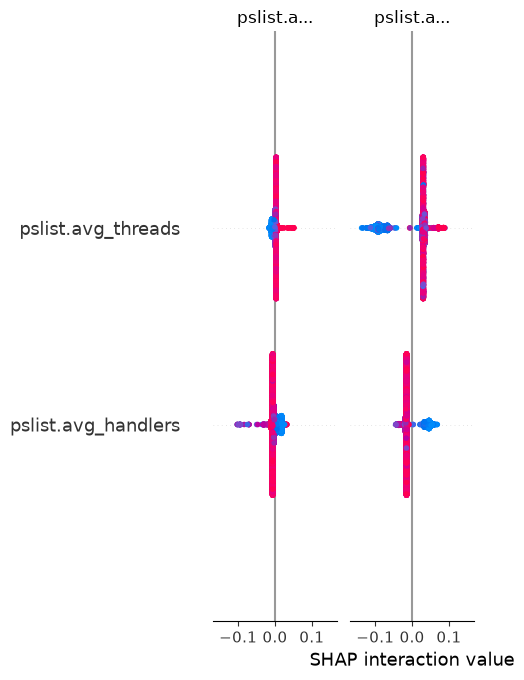

In [4]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

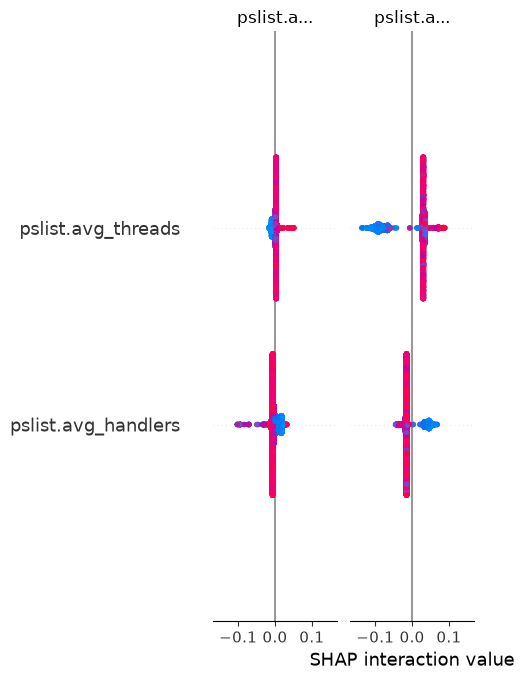

In [5]:
shap.summary_plot(
    shap_values,
    X_test
)

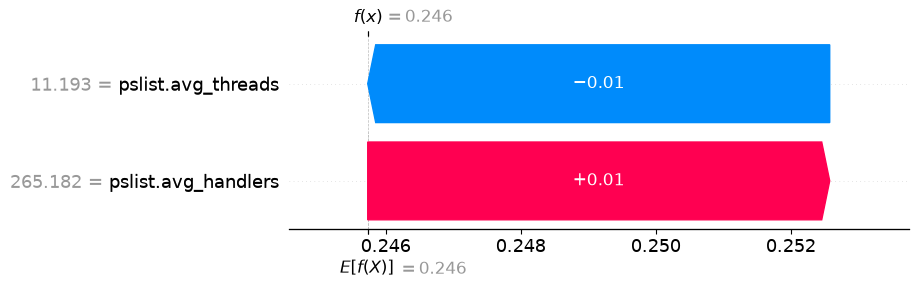

In [6]:
sample = 10

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][sample],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[sample],
        feature_names=feature_names
    )
)